In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sklearn
import torch
from stml.io import load_clean_data, load_returns_panel

print(f"torch {torch.__version__}  |  numpy {np.__version__}  |  pandas {pd.__version__}  |  sklearn {sklearn.__version__}")

TICKER_NAMES = {
    'cl1s': 'Crude Oil (CL)',
    'es1s': 'S&P 500 e-mini (ES)',
    'fesx1s': 'Euro Stoxx 50 (FESX)',
    'gc1s': 'Gold (GC)',
    'hg1s': 'Copper (HG)',
    'ho1s': 'Heating Oil (HO)',
    'ng1s': 'Natural Gas (NG)',
    'nq1s': 'Nasdaq 100 (NQ)',
    'pl1s': 'Platinum (PL)',
    'rb1s': 'RBOB Gasoline (RB)',
    'si1s': 'Silver (SI)',
}

torch 2.12.0+cpu  |  numpy 2.4.6  |  pandas 3.0.3  |  sklearn 1.8.0


In [40]:
DATA = Path('../..') / 'data'

ohlcv = pd.read_csv(DATA / 'ohlcv_data.csv')
signals = pd.read_csv(DATA / 'primary_signals.csv')

ohlcv_clean, signals_clean = load_clean_data()
ret_clean = load_returns_panel()

print(ohlcv.shape, signals.shape)
ohlcv.head()

(83547, 8) (645, 12)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


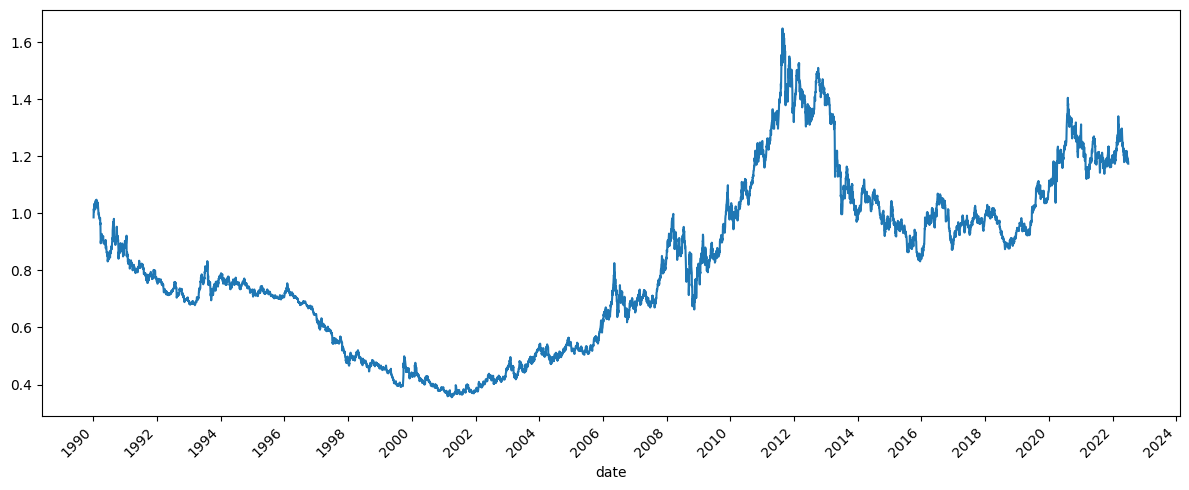

In [23]:
def get_returns_series(ohlcv: pd.DataFrame, instrument: str):
    df = ohlcv.set_index("date")
    df.index = pd.to_datetime(df.index) 
    df = df[df["instrument"] == instrument]
    df = np.log(df["close"]).diff().dropna()
    return df

# test
df = get_returns_series(ohlcv, "gc1s")

fig, ax = plt.subplots(figsize = (12,5))
(1 + df).cumprod().plot(ax = ax)

ax.xaxis.set_major_locator(mdates.YearLocator(2))  # tick every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
    

In [78]:
test_ohlcv = ohlcv_clean[ohlcv_clean["instrument"] == "gc1s"]
test_ohlc = test_ohlcv.set_index("date").drop(columns = ["instrument", "volume", "open_interest"])
test_ohlc

,open,high,low,close
date,,,,
1990-01-02,401.000000,404.600000,400.200000,402.100000
1990-01-03,398.600000,399.000000,394.500000,396.400000
1990-01-04,397.900000,401.100000,397.100000,400.800000
1990-01-05,404.500000,409.500000,402.500000,408.500000
1990-01-08,406.200000,407.600000,404.700000,405.000000
...,...,...,...,...
2022-06-24,727.158552,730.945420,724.567536,729.590120
2022-06-27,733.297265,734.572842,726.201869,727.397722
2022-06-28,726.919381,729.829291,725.125601,725.962698


In [102]:
signals_clean

,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
640,2022-06-24,-1,1,-1,1,0,1,0,1,1,1,1
641,2022-06-27,1,-1,-1,1,0,1,0,1,1,1,1
642,2022-06-28,1,1,-1,1,0,-1,0,1,1,1,1
643,2022-06-29,1,1,-1,1,0,-1,-1,1,1,1,0


In [109]:
test_signals = signals_clean["gc1s"]
test_signals.index = signals_clean["date"]
test_signals

date
2020-01-03    0
2020-01-06    0
2020-01-07    0
2020-01-08    0
2020-01-09    0
             ..
2022-06-24    1
2022-06-27    1
2022-06-28    1
2022-06-29    1
2022-06-30    1
Name: gc1s, Length: 645, dtype: int64

In [94]:
# compute atr
def compute_atr(ohlc: pd.DataFrame, window = 14):

    high = ohlc["high"]
    low = ohlc["low"]

    prev_close = ohlc["close"].shift(1)

    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis =1).max(axis = 1)
    
    # apply smoothing
    atr = tr.ewm(alpha = 1/window, adjust = False).mean() # set adjust = True to correct for early bias
    return atr

compute_atr(test_ohlc)

date
1990-01-02     4.400000
1990-01-03     4.628571
1990-01-04     4.633673
1990-01-05     4.924125
1990-01-08     4.843831
                ...    
2022-06-24    11.200436
2022-06-27    10.998332
2022-06-28    10.548714
2022-06-29    10.484274
2022-06-30    10.427284
Length: 8170, dtype: float64

In [ ]:
# make sure signal and ohlc time index are aligned 


In [ ]:


# get the label for each signal series
def get_trp_barr(signals: pd.Series, ohlc: pd.DataFrame, span: int, k_tp: float, k_sl: float):
    """
    Parameters
    ---
    signals : pd.Series
        signal series starting from 2020-01-03 to 2022-06-30
    ohlcv : pd.DataFrame
        instrument specific ohlcv data truncated to match window of signal series
    span : int
        how many indices we are looking forward
    vol_tp : float
        vol used for deciding  tp threshold
    vol_sl : float
        vol used for deciding sl threshold
    """
    atrs = compute_atr(ohlc)
    labels = []
    for start_date, row in ohlc.iterrows():
        if start_date == ohlc.index[-span]:
            break
        close = row["close"]
        label = 0
        s = signals.loc[start_date]
        atr = atrs.loc[start_date]
        end_date = start_date + pd.Timedelta(days = span)
        window_prices = ohlc.loc[start_date:end_date, "close"]    
        if s == 0:
            labels.append(label)
            continue
    
        elif s == 1: 
            tp_threshold = close + k_tp * atr
            sl_threshold = close - k_sl * atr

            if tp_threshold <= window_prices.values.max():
                label = 1 # price crosses above tp_threshold within window
            elif sl_threshold >= window_prices.values.min():
                label = 0 # price crosses below sl_threshold within window
            else: # price neither crosses both barriers
                label = 0
            
    
        elif s == -1:
            tp_threshold = close - k_tp * atr
            sl_threshold = close+ k_tp * atr

            if tp_threshold >= window_prices.values.min():
                label = 1 # price crosses below tp_threshold within window
            elif sl_threshold <= window_prices.values.max():
                label = 0 # price crosses above sl_thresohld within window
            else:
                label = 0 #
        labels.append(label)
    return labels


        
get_trp_barr(test_signals, test_ohlc, 20, 2,2)

KeyError: Timestamp('1990-01-02 00:00:00')

In [45]:
ohlcv

,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.800000,22.920000,21.790000,22.890000,2.286800e+04,6.630800e+04
1,1990-01-02,gc1s,401.000000,404.600000,400.200000,402.100000,2.074700e+04,6.885500e+04
2,1990-01-02,hg1s,1.047000,1.064000,1.043000,1.062000,3.325000e+03,1.973500e+04
3,1990-01-02,ho1s,0.747500,0.776000,0.741500,0.773900,2.028000e+04,3.373200e+04
4,1990-01-02,pl1s,484.000000,485.000000,479.500000,482.200000,4.561000e+03,1.325600e+04
...,...,...,...,...,...,...,...,...
83542,2022-06-30,ng1s,0.003710,0.003811,0.003092,0.003131,3.163010e+08,1.782334e+08
83543,2022-06-30,nq1s,8792.320096,8796.268236,8536.255006,8670.491771,9.814420e+05,3.361290e+05
83544,2022-06-30,pl1s,861.162113,867.492798,830.737031,845.949572,2.265265e+04,7.068317e+04
83545,2022-06-30,rb1s,10.780146,10.787487,10.124427,10.384307,2.208283e+04,3.142630e+04
